##Going to cover
1. prepare and load data
2. fitting model to data(training)
3. making predictions and evaluating a model(inference)
4. saving and loading a model
5. putting it all together

In [ ]:
import torch
from torch import nn #nn contains all building blocks of neural network
import matplotlib.pyplot as plt

torch.__version__


'2.11.0+cpu'

# 1. Data preparng and loading

data can be almost anything

* excel spreadsheet
* images
* videos  
* audio
* DNA
* text

# two parts of machine learning

1. Get data into a numerical representation.

2. build a model to learn patterns in that numerical model


To showcase this , let's create some *known* data usind the linear regression formula.

we'll use a linear regression formula to make a straight line with *known* **parameters**

In [ ]:
# create known parameters

weight=0.7 #b
bias=0.3 #a

start=0
end=1
step=0.02

X=torch.arange(start,end,step).unsqueeze(dim=1)
Y=weight*X + bias
X[:10], Y[:10], len(X), len(Y)

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]),
 50,
 50)

#splitting data into training and test sets

In [ ]:
#create a train/test split
train_split=int(0.8*len(X))
X_train, Y_train=X[:train_split],Y[ :train_split]
X_test,Y_test=X[train_split:],Y[train_split:]

len(X_train), len(Y_train), len(X_test), len(Y_test)

(40, 40, 10, 10)

#How might we better visualize our data ?



In [ ]:
def plot_predictions (train_data=X_train,
                     train_label=Y_train,
                     test_data=X_test,
                     test_label=Y_test,
                     predictions=None):

  """plot training data and test data and compare predictionns"""
  plt.figure(figsize=(10,7))

  #plot training data in blue
  plt.scatter(train_data,train_label,c="b",s=4,label="training data")

  #plot test data in green
  plt.scatter(test_data,test_label,c='g',s=4,label="testing data")

  #are there predictions
  if predictions is not None:
    #plot predictions in red
    plt.scatter(test_data,predictions,c="r",s=4,label="predictions")

  #show legend
  plt.legend(prop={"size":14})

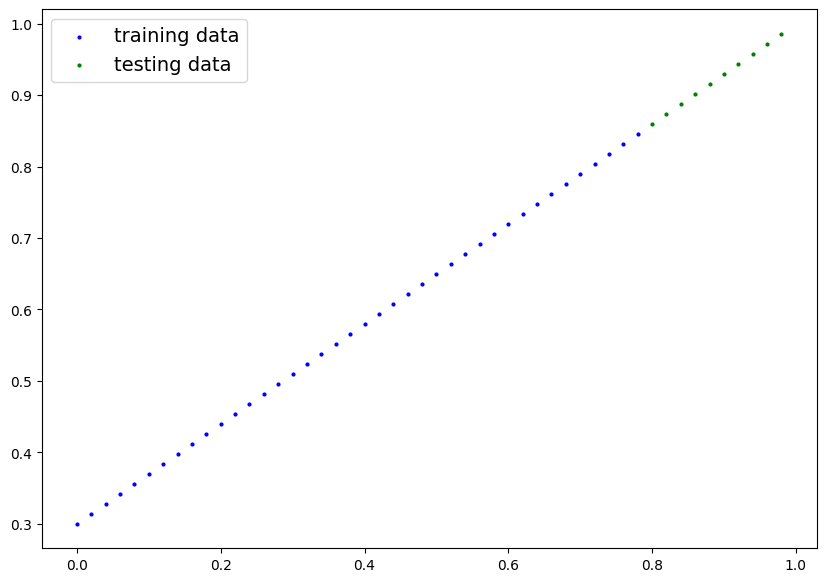

In [ ]:


plot_predictions();

#Build model

First pytorch model
* start with random values(weight&bias)
* look at the training data and adjust the random values to better represent (or get closer to) the ideal values (the weight & bias values we used to create the data)

How does is it do so?
* gradient decet
* backpropagation

In [ ]:
#create linear regression model class
from torch import nn
class LinearRegressionModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.weights=nn.Parameter(torch.rand(1,
                                         requires_grad=True,
                                         dtype=torch.float))
    self.bias=nn.Parameter(torch.rand(1,
                                      requires_grad=True,
                                      dtype=torch.float))
   #forward method to define the computation in the model
  def forward(self,x:torch.Tensor) -> torch.Tensor:
    return self.weights * x + self.bias


#PyTorch model building essentials

* torch.nn contains all of the buildings for computational graphs( a nueral can be considered a computational task)

* torch.nn.parameter-what parameter should our model try and learn, often a PyTorh layer from torch.nn will set these for us

* torch.nn.Module - the base class for all neural network modules, if you subclass it,you should overwrite forward()

* torch.optim - this is where the optimizers in PyTorch live, they will help with gradient descent

* def forward() - all nn.Module subclasses require you to overwrite forward(), this method defines what happens in the forward computation

#Checking the contents of our PyTorch model

Now we've created a model, let's see what's inside..


we can check our model parameters or what's inside our model using .parameters().



In [ ]:
#create a random seed

torch.manual_seed(42)

#create a instance of the model(this is a subclass of nn.Module)

model_0 = LinearRegressionModel()
#check out the parameters
list(model_0.parameters())


[Parameter containing:
 tensor([0.8823], requires_grad=True),
 Parameter containing:
 tensor([0.9150], requires_grad=True)]

In [ ]:
#list named parameters

model_0.state_dict()

OrderedDict([('weights', tensor([0.8823])), ('bias', tensor([0.9150]))])

#Making predictions using 'torch.inference_mode()'

To check our model's predictive power, let's see how well it predicts 'Y_test' based on 'X_test'

when we pass data through our model, it's going to run it through the 'forward()' method.



In [ ]:
X_test,Y_test

(tensor([[0.8000],
         [0.8200],
         [0.8400],
         [0.8600],
         [0.8800],
         [0.9000],
         [0.9200],
         [0.9400],
         [0.9600],
         [0.9800]]),
 tensor([[0.8600],
         [0.8740],
         [0.8880],
         [0.9020],
         [0.9160],
         [0.9300],
         [0.9440],
         [0.9580],
         [0.9720],
         [0.9860]]))

In [ ]:
y_pres=model_0(X_test)
y_pres

tensor([[1.6208],
        [1.6385],
        [1.6561],
        [1.6738],
        [1.6914],
        [1.7090],
        [1.7267],
        [1.7443],
        [1.7620],
        [1.7796]], grad_fn=<AddBackward0>)

In [ ]:
 #make predictions with model

with torch.inference_mode():
  y_preds=model_0(X_test)
y_preds





tensor([[1.6208],
        [1.6385],
        [1.6561],
        [1.6738],
        [1.6914],
        [1.7090],
        [1.7267],
        [1.7443],
        [1.7620],
        [1.7796]])

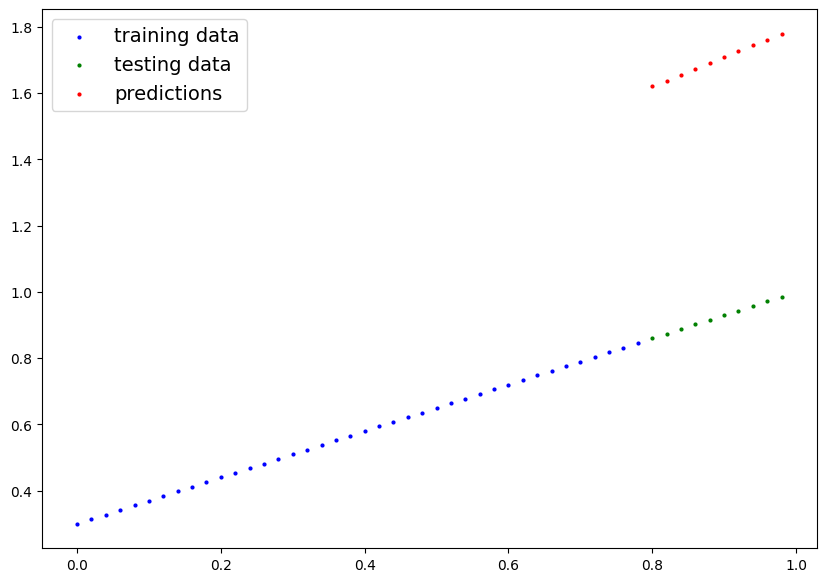

In [ ]:
plot_predictions(predictions=y_preds)

#Train model

The whole idea of training is for a a model to move from unknowm parameter to known parameter.

or in other words from a poor reprsentation to a better reprensentation.

One way to measure how poor or how wrong your models predictions are is to use a loss function.

*note: loss func is also called as cost func or criterion.

#Things we need to train:

* **Loss function:** A function to measure how wrong your model's predictions are to the ideal outputs. The lower is better.

* **Optimizer:** Takes into account the loss of a model and adjust the model's parameters(eg:weight,bias) to improve loss function.

And specifically for PyTorch,we need

  * Training loop
  * Testing loop




In [ ]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.8823], requires_grad=True),
 Parameter containing:
 tensor([0.9150], requires_grad=True)]

In [ ]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.8823])), ('bias', tensor([0.9150]))])

##Creating training model

In [ ]:
#Setup a loss function

loss_fn=nn.L1Loss()


#Setup a optimizer(stochastic gradient descent)
optimizer=torch.optim.SGD(params=model_0.parameters(),lr=0.01) #lr=learning rate=possibly the most important hyperparameter you can set


##Building a training loop and testing loop

Things we need in a training loop:

0. Loop through the data
1. Forward pass(this involves data moving through our model's forward function) - also called forward propagation
2. calculate the loss(compare forward pass predictions and ground truth table)
3. optimizer zero grad
4. loss backward-moves backward throigh the network to claculate the gradient of each of the parameters of our model with respect to the loss (**Backpropagation**)
5. optimizer step - use the optimizer to adjust our model's parameters to try and improve the loss

In [ ]:

with torch.no_grad():
  list(model_0.parameters())

In [ ]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.8823])), ('bias', tensor([0.9150]))])

In [ ]:
#an epoch is one loop through the data...(this is a hyper parameter cozz we set it ourselves)

epochs=10000

###Training
#0.Loop through the data
for epoch in range(epochs):
  #set the model to training model
  model_0.train() #train mode in pytorch sets all parameters that require gradients to require gradients

  #1.Forward pass
  y_preds=model_0(X_train)

  #2. Calculate loss
  loss=loss_fn(y_preds,Y_train)

  #3. Optimizer zero grad
  optimizer.zero_grad()

  #4. perform back propagation on the loss with respect to the parameters of the model
  loss.backward()

  #5.step the optimizer(perform gradient decent)
  optimizer.step() #by default hoe the optimizer chnages will accumulate through the loop so we have to zero them above in step 3 for the next iteration of the loop


  ###Testing

  model_0.eval() #turns off gradient tracking






In [ ]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6977])), ('bias', tensor([0.3080]))])

In [ ]:
y_preds

tensor([[0.8661],
        [0.8801],
        [0.8940],
        [0.9080],
        [0.9220],
        [0.9359],
        [0.9499],
        [0.9638],
        [0.9778],
        [0.9917]])

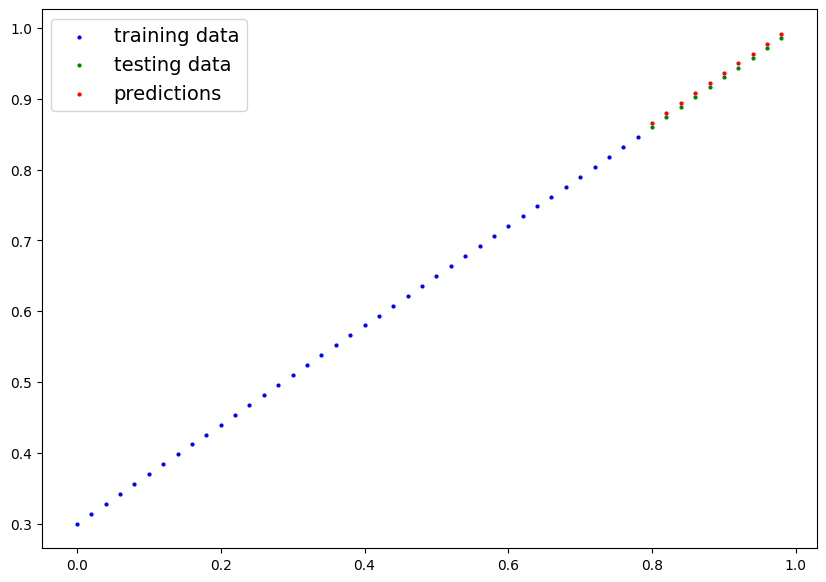

In [ ]:
model_0.eval()
with torch.inference_mode():
  # Make predictions on the test data
  y_preds = model_0(X_test)

plot_predictions(predictions=y_preds.detach())